# Crema-D Audio Detection of Emotion

In [ ]:
import librosa, numpy as np, pandas as pd, os, re, json, collections
from tqdm import tqdm
from pathlib import Path
import kagglehub
import soundfile as sf
import matplotlib.pyplot as plt
import random
from IPython.display import Audio, display


In [ ]:
import kagglehub

path = kagglehub.dataset_download("ejlok1/cremad")
print("Downloaded to:", path)


Using Colab cache for faster access to the 'cremad' dataset.
Downloaded to: /kaggle/input/cremad


## Inspecting Data

In [ ]:
root = Path(path)
list(root.iterdir())


[PosixPath('/kaggle/input/cremad/AudioWAV')]

### Verifying Audio files

In [ ]:
from pathlib import Path
import librosa, numpy as np, pandas as pd, os, re, json, collections

wav_dir = Path(path) / "AudioWAV"
files = sorted(wav_dir.glob("*.wav"))
print("Total WAV files:", len(files))

if len(files) == 0:
    print("No WAV files found in:", wav_dir)
else:
    # Basic sampling rate + duration check
    sample_rates, durations = {}, []
    for f in files[:100]:
        y, sr = librosa.load(f, sr=None, mono=True)
        sample_rates[sr] = sample_rates.get(sr, 0) + 1
        durations.append(len(y) / sr)

    print("Sample rate counts (sampled 100):", sample_rates)
    print("Duration range (sec):", np.min(durations), "-", np.max(durations))

    # Label + speaker verification
    emo_pattern = re.compile(r'_(ANG|DIS|FEA|HAP|NEU|SAD)_')
    emotions, speakers = [], []
    for f in files:
        name = f.name
        emo = emo_pattern.search(name)
        if emo:
            emotions.append(emo.group(1))
        speakers.append(name.split('_')[0])

    print("Emotion counts (approx):", collections.Counter(emotions))
    print("Unique speakers:", len(set(speakers)))


Total WAV files: 7442
Sample rate counts (sampled 100): {16000: 100}
Duration range (sec): 1.534875 - 3.2031875
Emotion counts (approx): Counter({'ANG': 1271, 'DIS': 1271, 'FEA': 1271, 'HAP': 1271, 'SAD': 1271, 'NEU': 1087})
Unique speakers: 91


## Mapping datasets to classes

In [ ]:
records = []
for f in files:
    name = f.name
    parts = name.split("_")
    speaker_id = parts[0]         # e.g. 1001
    emotion = parts[2].upper()    # e.g. ANG
    records.append({
        "filepath": f.name,       # just filename relative to AudioWAV folder
        "speaker_id": speaker_id,
        "emotion": emotion
    })

df = pd.DataFrame(records)
df.to_csv("metadata.csv", index=False)
print("Saved metadata.csv with", len(df), "rows")
print(df.head())


Saved metadata.csv with 7442 rows
              filepath speaker_id emotion
0  1001_DFA_ANG_XX.wav       1001     ANG
1  1001_DFA_DIS_XX.wav       1001     DIS
2  1001_DFA_FEA_XX.wav       1001     FEA
3  1001_DFA_HAP_XX.wav       1001     HAP
4  1001_DFA_NEU_XX.wav       1001     NEU


     class  num_audio
0    angry       1271
1  disgust       1271
2     fear       1271
3    happy       1271
4  neutral       1087
5      sad       1271


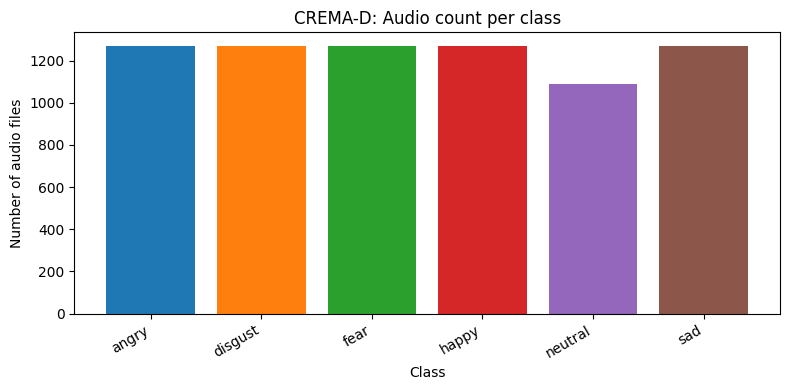

In [ ]:
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# ✅ change this to your actual folder
audio_wav_dir = wav_dir

labels_mapping = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad",
}

def get_emo_code(fname):
    if not fname.lower().endswith(".wav"):
        return None
    parts = fname.split("_")
    if len(parts) < 4:
        return None
    return parts[2]  # ANG/HAP/SAD/...

counts = Counter()

for fname in os.listdir(audio_wav_dir):
    emo = get_emo_code(fname)
    if emo in labels_mapping:
        counts[labels_mapping[emo]] += 1

df = pd.DataFrame(sorted(counts.items()), columns=["class", "num_audio"])
print(df)

cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = [cycle[i % len(cycle)] for i in range(len(df))]

plt.figure(figsize=(8,4))
plt.bar(df["class"], df["num_audio"], color=colors)
plt.xlabel("Class")
plt.ylabel("Number of audio files")
plt.title("CREMA-D: Audio count per class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("ejlok1/cremad")
print("Dataset path:", path)

audio_src = Path(path) / "AudioWAV"
print("WAV count:", len(list(audio_src.glob("*.wav"))))


Using Colab cache for faster access to the 'cremad' dataset.
Dataset path: /kaggle/input/cremad
WAV count: 7442


In [ ]:
audio_src

PosixPath('/kaggle/input/cremad/AudioWAV')

In [ ]:
audio_src = Path(path) / "AudioWAV"

!mkdir -p emotion_audio_project/data/raw_audio
!cp -r "{audio_src}"/* emotion_audio_project/data/raw_audio/
!mv metadata.csv emotion_audio_project/data/


In [ ]:
!mkdir -p emotion_audio_project/data/raw_audio
!cp -r /root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1/AudioWAV/* emotion_audio_project/data/raw_audio/
!mv metadata.csv emotion_audio_project/data/

cp: cannot stat '/root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1/AudioWAV/*': No such file or directory
mv: cannot stat 'metadata.csv': No such file or directory


## Preprocessing Data

In [ ]:
raw_audio_dir = Path("/root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1/AudioWAV")
metadata_path = Path("/content/emotion_audio_project/data/metadata.csv")
work_dir = Path("/content/emotion_audio_project/data/processed")
work_dir.mkdir(parents=True, exist_ok=True)
feat_dir = work_dir / "features"
feat_dir.mkdir(exist_ok=True)

print("Audio path:", raw_audio_dir)

Audio path: /root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1/AudioWAV


In [ ]:
df = pd.read_csv(metadata_path)
print(df.head())
print("Rows:", len(df))

              filepath  speaker_id emotion
0  1001_DFA_ANG_XX.wav        1001     ANG
1  1001_DFA_DIS_XX.wav        1001     DIS
2  1001_DFA_FEA_XX.wav        1001     FEA
3  1001_DFA_HAP_XX.wav        1001     HAP
4  1001_DFA_NEU_XX.wav        1001     NEU
Rows: 7442


In [ ]:
def load_audio(path, sr=16000):
    y, s = librosa.load(path, sr=sr, mono=True)
    return y, s

def trim_and_normalize(y, top_db=30, target_dbfs=-1.0):
    yt, _ = librosa.effects.trim(y, top_db=top_db)
    peak = np.max(np.abs(yt)) + 1e-9
    scale = (10**(target_dbfs/20.0)) / peak
    return yt * min(scale, 1.0)

def to_logmel(y, sr=16000, n_mels=64):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmin=50, fmax=8000)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db.astype(np.float32)

## Ransford's code

In [ ]:
features = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    wav_path = audio_src / row["filepath"]
    y, sr = load_audio(wav_path)
    y = trim_and_normalize(y)
    F = to_logmel(y, sr)
    out_path = feat_dir / f"{Path(row['filepath']).stem}.npy"
    np.save(out_path, F)
    features.append({
        "id": Path(row["filepath"]).stem,
        "feature_path": str(out_path.relative_to(work_dir)),
        "label": row["emotion"],
        "speaker_id": row["speaker_id"],
        "n_frames": F.shape[1]
    })

pd.DataFrame(features).to_csv(work_dir / "index.csv", index=False)
print("Saved:", work_dir / "index.csv")

100%|██████████| 7442/7442 [01:01<00:00, 120.25it/s]

Saved: /content/emotion_audio_project/data/processed/index.csv


In [ ]:
features = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    wav_path = audio_src / row["filepath"]
    y, sr = load_audio(wav_path)
    y = trim_and_normalize(y)
    F = to_logmel(y, sr)
    out_path = feat_dir / f"{Path(row['filepath']).stem}.npy"
    np.save(out_path, F)
    features.append({
        "id": Path(row["filepath"]).stem,
        "feature_path": str(out_path.relative_to(work_dir)),
        "label": row["emotion"],
        "speaker_id": row["speaker_id"],
        "n_frames": F.shape[1]
    })

pd.DataFrame(features).to_csv(work_dir / "index.csv", index=False)
print("Saved:", work_dir / "index.csv")

100%|██████████| 7442/7442 [01:09<00:00, 107.84it/s]

Saved: /content/emotion_audio_project/data/processed/index.csv


In [ ]:
df.head()[["filepath"]]


,filepath
0,1001_DFA_ANG_XX.wav
1,1001_DFA_DIS_XX.wav
2,1001_DFA_FEA_XX.wav
3,1001_DFA_HAP_XX.wav
4,1001_DFA_NEU_XX.wav


## Ransford

In [ ]:
from pathlib import Path

print("raw_audio_dir currently:", audio_src)
print("WAV files found there:", len(list(Path(audio_src).glob("*.wav"))))


raw_audio_dir currently: /kaggle/input/cremad/AudioWAV
WAV files found there: 7442


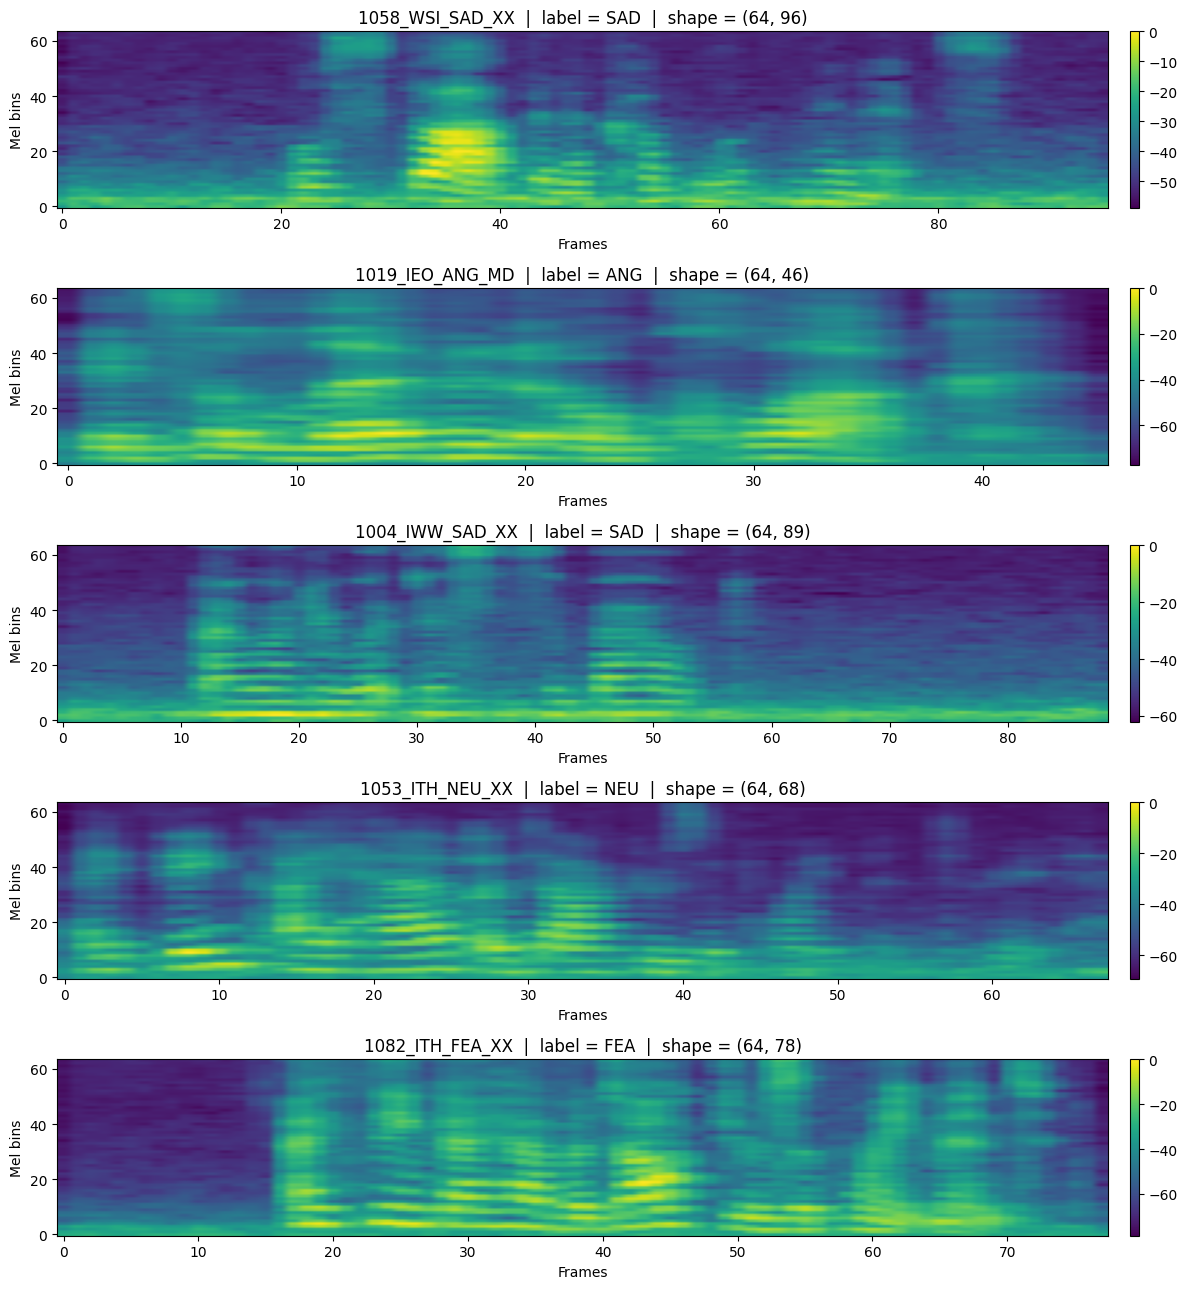

Audio preview (original files):
1. 1058_WSI_SAD_XX  →  SAD


2. 1019_IEO_ANG_MD  →  ANG


3. 1004_IWW_SAD_XX  →  SAD


4. 1053_ITH_NEU_XX  →  NEU


5. 1082_ITH_FEA_XX  →  FEA


In [ ]:

WORK_DIR = Path("/content/emotion_audio_project/data/processed")
RAW_AUDIO_DIR = Path("/content/emotion_audio_project/data/raw_audio")  # original wavs live here

# Load the processed index
df_idx = pd.read_csv(WORK_DIR / "index.csv")
assert {"id","feature_path","label"}.issubset(df_idx.columns), "index.csv missing required columns"

# Pick 5 examples (stratified-ish by label if you want; here: simple random)
N = 5
picked = df_idx.sample(N, random_state=1337).reset_index(drop=True)

# Plot 5 spectrograms (one per row)
fig, axes = plt.subplots(N, 1, figsize=(12, 2.6*N))
if N == 1:
    axes = [axes]

for i, row in picked.iterrows():
    feat_path = WORK_DIR / row["feature_path"]
    arr = np.load(feat_path)   # shape: (n_mels, T)
    im = axes[i].imshow(arr, aspect="auto", origin="lower")
    axes[i].set_title(f"{row['id']}  |  label = {row['label']}  |  shape = {arr.shape}")
    axes[i].set_xlabel("Frames")
    axes[i].set_ylabel("Mel bins")
    fig.colorbar(im, ax=axes[i], fraction=0.015, pad=0.02)

plt.tight_layout()
plt.show()

# Audio players (original WAV) with labels
print("Audio preview (original files):")
for i, row in picked.iterrows():
    wav_path = audio_src / f"{row['id']}.wav"
    if not wav_path.exists():
        # Fallback: some datasets keep full filename in 'id'; try that
        alt = list(RAW_AUDIO_DIR.glob(f"{row['id']}*.wav"))
        wav_path = alt[0] if alt else None

    print(f"{i+1}. {row['id']}  →  {row['label']}")
    if wav_path and wav_path.exists():
        y, sr = librosa.load(wav_path, sr=None, mono=True)  # native CREMA-D sr=16k
        display(Audio(data=y, rate=sr))
    else:
        print("   (WAV not found — check RAW_AUDIO_DIR and id/filenames)")



## Dharsh

In [ ]:
from pathlib import Path

print("raw_audio_dir currently:", raw_audio_dir)
print("WAV files found there:", len(list(Path(raw_audio_dir).glob("*.wav"))))


raw_audio_dir currently: /root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1/AudioWAV
WAV files found there: 0


In [ ]:
from pathlib import Path

# 'path' is what kagglehub.dataset_download("ejlok1/cremad") returned
raw_audio_dir = Path(path) / "AudioWAV"

print("raw_audio_dir set to:", raw_audio_dir)
print("WAV files found there:", len(list(raw_audio_dir.glob("*.wav"))))


raw_audio_dir set to: /kaggle/input/cremad/AudioWAV
WAV files found there: 7442


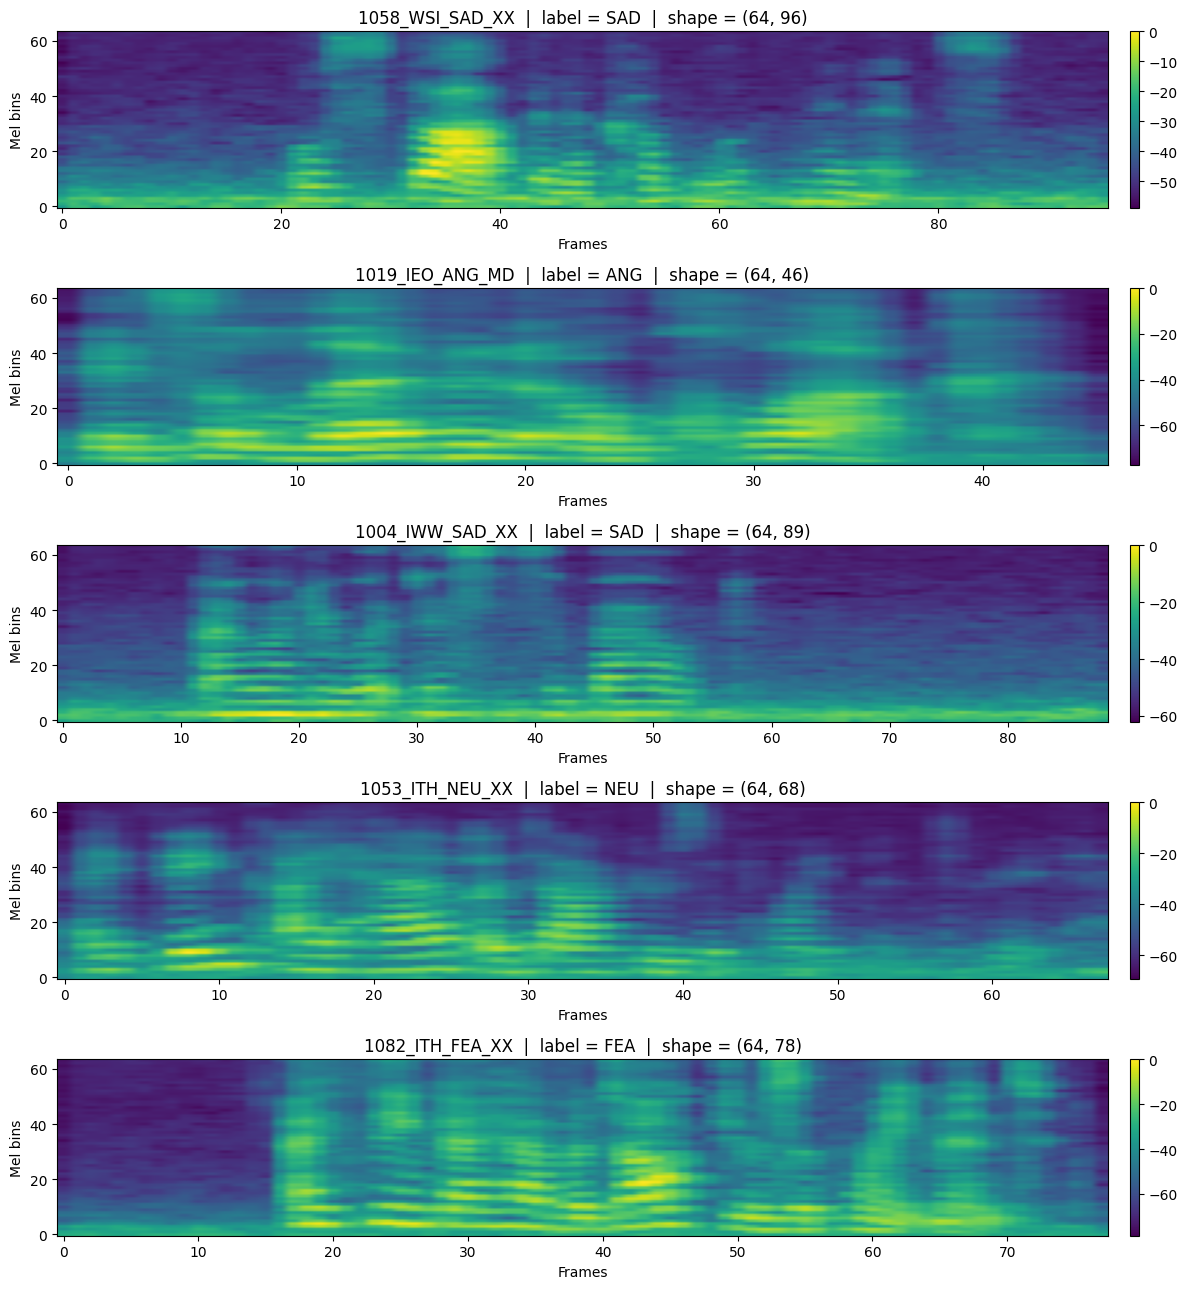

Audio preview (original files):
1. 1058_WSI_SAD_XX  →  SAD


2. 1019_IEO_ANG_MD  →  ANG


3. 1004_IWW_SAD_XX  →  SAD


4. 1053_ITH_NEU_XX  →  NEU


5. 1082_ITH_FEA_XX  →  FEA


In [ ]:

WORK_DIR = Path("/content/emotion_audio_project/data/processed")
RAW_AUDIO_DIR = Path("/content/emotion_audio_project/data/raw_audio")  # original wavs live here

# Load the processed index
df_idx = pd.read_csv(WORK_DIR / "index.csv")
assert {"id","feature_path","label"}.issubset(df_idx.columns), "index.csv missing required columns"

# Pick 5 examples (stratified-ish by label if you want; here: simple random)
N = 5
picked = df_idx.sample(N, random_state=1337).reset_index(drop=True)

# Plot 5 spectrograms (one per row)
fig, axes = plt.subplots(N, 1, figsize=(12, 2.6*N))
if N == 1:
    axes = [axes]

for i, row in picked.iterrows():
    feat_path = WORK_DIR / row["feature_path"]
    arr = np.load(feat_path)   # shape: (n_mels, T)
    im = axes[i].imshow(arr, aspect="auto", origin="lower")
    axes[i].set_title(f"{row['id']}  |  label = {row['label']}  |  shape = {arr.shape}")
    axes[i].set_xlabel("Frames")
    axes[i].set_ylabel("Mel bins")
    fig.colorbar(im, ax=axes[i], fraction=0.015, pad=0.02)

plt.tight_layout()
plt.show()

# Audio players (original WAV) with labels
print("Audio preview (original files):")
for i, row in picked.iterrows():
    wav_path = RAW_AUDIO_DIR / f"{row['id']}.wav"
    if not wav_path.exists():
        # Fallback: some datasets keep full filename in 'id'; try that
        alt = list(RAW_AUDIO_DIR.glob(f"{row['id']}*.wav"))
        wav_path = alt[0] if alt else None

    print(f"{i+1}. {row['id']}  →  {row['label']}")
    if wav_path and wav_path.exists():
        y, sr = librosa.load(wav_path, sr=None, mono=True)  # native CREMA-D sr=16k
        display(Audio(data=y, rate=sr))
    else:
        print("   (WAV not found — check RAW_AUDIO_DIR and id/filenames)")



## Label encoding and train/validation/test split

In [ ]:
from pathlib import Path
import pandas as pd

work_dir = Path(work_dir)   # reuse existing variable
index_path = work_dir / "index.csv"

df_idx = pd.read_csv(index_path)
df_idx.head()

,id,feature_path,label,speaker_id,n_frames
0,1001_DFA_ANG_XX,features/1001_DFA_ANG_XX.npy,ANG,1001,59
1,1001_DFA_DIS_XX,features/1001_DFA_DIS_XX.npy,DIS,1001,73
2,1001_DFA_FEA_XX,features/1001_DFA_FEA_XX.npy,FEA,1001,29
3,1001_DFA_HAP_XX,features/1001_DFA_HAP_XX.npy,HAP,1001,48
4,1001_DFA_NEU_XX,features/1001_DFA_NEU_XX.npy,NEU,1001,64


In [ ]:
# make sure labels are strings
df_idx["label"] = df_idx["label"].astype(str)

unique_labels = sorted(df_idx["label"].unique())
emotion_to_idx = {emo: i for i, emo in enumerate(unique_labels)}
idx_to_emotion = {i: emo for emo, i in emotion_to_idx.items()}

df_idx["label_idx"] = df_idx["label"].map(emotion_to_idx)

emotion_to_idx

{'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}

In [ ]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.15      # 15% test
VAL_FRAC = 0.15       # 15% of remaining train used as val

speakers = df_idx["speaker_id"].unique()
train_spk, test_spk = train_test_split(
    speakers, test_size=0.15, random_state=42
)
train_spk, val_spk = train_test_split(
    train_spk, test_size=0.15, random_state=42
)

train_df = df_idx[df_idx["speaker_id"].isin(train_spk)]
val_df   = df_idx[df_idx["speaker_id"].isin(val_spk)]
test_df  = df_idx[df_idx["speaker_id"].isin(test_spk)]
# train_full, test_df = train_test_split(
#     df_idx,
#     test_size=TEST_SIZE,
#     stratify=df_idx["label_idx"],
#     random_state=42,
# )

# train_df, val_df = train_test_split(
#     train_full,
#     test_size=VAL_FRAC,
#     stratify=train_full["label_idx"],
#     random_state=42,
# )

len(train_df), len(val_df), len(test_df)

(5311, 983, 1148)

In [ ]:
print("Train labels:\n", train_df["label"].value_counts(), "\n")
print("Val labels:\n",   val_df["label"].value_counts(), "\n")
print("Test labels:\n",  test_df["label"].value_counts())

Train labels:
 label
ANG    907
DIS    907
FEA    907
HAP    907
SAD    907
NEU    776
Name: count, dtype: int64 

Val labels:
 label
ANG    168
DIS    168
FEA    168
HAP    168
SAD    168
NEU    143
Name: count, dtype: int64 

Test labels:
 label
ANG    196
DIS    196
FEA    196
HAP    196
SAD    196
NEU    168
Name: count, dtype: int64


## MFCC feature extraction

In [ ]:
from pathlib import Path
import librosa
import numpy as np

mfcc_feat_dir = work_dir / "mfcc_features"
mfcc_feat_dir.mkdir(parents=True, exist_ok=True)
print("MFCC feature dir:", mfcc_feat_dir)

def to_mfcc(y, sr, n_mfcc=20, n_fft=512, hop_length=160, win_length=400):
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
    )
    return mfcc.astype(np.float32)

MFCC feature dir: /content/emotion_audio_project/data/processed/mfcc_features


## Ransford

In [ ]:
from tqdm import tqdm
import pandas as pd

mfcc_records = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    fname = row["filepath"]
    wav_path = audio_src / fname

    if not wav_path.exists():
        print("MISSING:", wav_path)
        continue

    y, sr = load_audio(wav_path)
    y = trim_and_normalize(y)
    M = to_mfcc(y, sr)                      # (n_mfcc, T)

    out_path = mfcc_feat_dir / f"{Path(fname).stem}_mfcc.npy"
    np.save(out_path, M)

    mfcc_records.append({
        "id": Path(fname).stem,
        "mfcc_path": str(out_path.relative_to(work_dir)),
        "label": row["emotion"],
        "speaker_id": row["speaker_id"],
        "n_frames_mfcc": M.shape[1],
    })

df_mfcc = pd.DataFrame(mfcc_records)
mfcc_index_path = work_dir / "index_mfcc.csv"
df_mfcc.to_csv(mfcc_index_path, index=False)

print("Saved MFCC index to:", mfcc_index_path)
df_mfcc.head()

100%|██████████| 7442/7442 [01:06<00:00, 112.56it/s]


Saved MFCC index to: /content/emotion_audio_project/data/processed/index_mfcc.csv


,id,mfcc_path,label,speaker_id,n_frames_mfcc
0,1001_DFA_ANG_XX,mfcc_features/1001_DFA_ANG_XX_mfcc.npy,ANG,1001,186
1,1001_DFA_DIS_XX,mfcc_features/1001_DFA_DIS_XX_mfcc.npy,DIS,1001,234
2,1001_DFA_FEA_XX,mfcc_features/1001_DFA_FEA_XX_mfcc.npy,FEA,1001,90
3,1001_DFA_HAP_XX,mfcc_features/1001_DFA_HAP_XX_mfcc.npy,HAP,1001,151
4,1001_DFA_NEU_XX,mfcc_features/1001_DFA_NEU_XX_mfcc.npy,NEU,1001,204


## Dharsh

In [ ]:
from tqdm import tqdm
import pandas as pd

mfcc_records = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    fname = row["filepath"]
    wav_path = raw_audio_dir / fname

    if not wav_path.exists():
        print("MISSING:", wav_path)
        continue

    y, sr = load_audio(wav_path)
    y = trim_and_normalize(y)
    M = to_mfcc(y, sr)                      # (n_mfcc, T)

    out_path = mfcc_feat_dir / f"{Path(fname).stem}_mfcc.npy"
    np.save(out_path, M)

    mfcc_records.append({
        "id": Path(fname).stem,
        "mfcc_path": str(out_path.relative_to(work_dir)),
        "label": row["emotion"],
        "speaker_id": row["speaker_id"],
        "n_frames_mfcc": M.shape[1],
    })

df_mfcc = pd.DataFrame(mfcc_records)
mfcc_index_path = work_dir / "index_mfcc.csv"
df_mfcc.to_csv(mfcc_index_path, index=False)

print("Saved MFCC index to:", mfcc_index_path)
df_mfcc.head()

100%|██████████| 7442/7442 [01:04<00:00, 115.81it/s]


Saved MFCC index to: /content/emotion_audio_project/data/processed/index_mfcc.csv


,id,mfcc_path,label,speaker_id,n_frames_mfcc
0,1001_DFA_ANG_XX,mfcc_features/1001_DFA_ANG_XX_mfcc.npy,ANG,1001,186
1,1001_DFA_DIS_XX,mfcc_features/1001_DFA_DIS_XX_mfcc.npy,DIS,1001,234
2,1001_DFA_FEA_XX,mfcc_features/1001_DFA_FEA_XX_mfcc.npy,FEA,1001,90
3,1001_DFA_HAP_XX,mfcc_features/1001_DFA_HAP_XX_mfcc.npy,HAP,1001,151
4,1001_DFA_NEU_XX,mfcc_features/1001_DFA_NEU_XX_mfcc.npy,NEU,1001,204


In [ ]:
df_mfcc = pd.read_csv(work_dir / "index_mfcc.csv")
df_mfcc_small = df_mfcc[["id", "mfcc_path"]]

train_df_cb = train_df.merge(df_mfcc_small, on="id")
val_df_cb   = val_df.merge(df_mfcc_small,   on="id")
test_df_cb  = test_df.merge(df_mfcc_small,  on="id")

print(train_df_cb.shape, val_df_cb.shape, test_df_cb.shape)
train_df_cb.head()

(5311, 7) (983, 7) (1148, 7)


,id,feature_path,label,speaker_id,n_frames,label_idx,mfcc_path
0,1002_DFA_ANG_XX,features/1002_DFA_ANG_XX.npy,ANG,1002,45,0,mfcc_features/1002_DFA_ANG_XX_mfcc.npy
1,1002_DFA_DIS_XX,features/1002_DFA_DIS_XX.npy,DIS,1002,80,1,mfcc_features/1002_DFA_DIS_XX_mfcc.npy
2,1002_DFA_FEA_XX,features/1002_DFA_FEA_XX.npy,FEA,1002,86,2,mfcc_features/1002_DFA_FEA_XX_mfcc.npy
3,1002_DFA_HAP_XX,features/1002_DFA_HAP_XX.npy,HAP,1002,68,3,mfcc_features/1002_DFA_HAP_XX_mfcc.npy
4,1002_DFA_NEU_XX,features/1002_DFA_NEU_XX.npy,NEU,1002,79,4,mfcc_features/1002_DFA_NEU_XX_mfcc.npy


In [ ]:
def build_stat_features_combined(df_split, work_dir):
    X_list, y_list = [], []

    for _, row in df_split.iterrows():
        mel = np.load(work_dir / row["feature_path"])   # (n_mels, T1)
        mfcc = np.load(work_dir / row["mfcc_path"])     # (n_mfcc, T2)

        def stats(F):
            m = F.mean(axis=1)
            s = F.std(axis=1)
            return np.concatenate([m, s])

        mel_vec = stats(mel)
        mfcc_vec = stats(mfcc)
        feat_vec = np.concatenate([mel_vec, mfcc_vec])

        X_list.append(feat_vec)
        y_list.append(int(row["label_idx"]))

    X = np.stack(X_list, axis=0)
    y = np.array(y_list)
    return X, y

In [ ]:
X_train_clf, y_train_clf = build_stat_features_combined(train_df_cb, work_dir)
X_val_clf,   y_val_clf   = build_stat_features_combined(val_df_cb,   work_dir)
X_test_clf,  y_test_clf  = build_stat_features_combined(test_df_cb,  work_dir)

X_train_clf.shape, X_val_clf.shape, X_test_clf.shape

((5311, 168), (983, 168), (1148, 168))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

logreg_clf = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    n_jobs=-1
)

logreg_clf.fit(X_train_clf, y_train_clf)

y_val_pred_lr = logreg_clf.predict(X_val_clf)
y_test_pred_lr = logreg_clf.predict(X_test_clf)

val_acc_lr = accuracy_score(y_val_clf, y_val_pred_lr)
test_acc_lr = accuracy_score(y_test_clf, y_test_pred_lr)

val_f1_lr = f1_score(y_val_clf, y_val_pred_lr, average="weighted")
test_f1_lr = f1_score(y_test_clf, y_test_pred_lr, average="weighted")

val_acc_lr, test_acc_lr, val_f1_lr, test_f1_lr

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


(0.4933875890132248,
 0.4616724738675958,
 0.4871742729873253,
 0.4579830152338929)

## Deep-learning model on log-Mel spectrograms

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

NUM_CLASSES = len(unique_labels)
print("NUM_CLASSES:", NUM_CLASSES)

MAX_FRAMES = int(train_df["n_frames"].quantile(0.95))
print("MAX_FRAMES:", MAX_FRAMES)

Device: cuda
NUM_CLASSES: 6
MAX_FRAMES: 109


In [ ]:
import numpy as np

class MelEmotionDataset(Dataset):
    def __init__(self, df_split, work_dir, max_frames, augment=False):
        self.df = df_split.reset_index(drop=True)
        self.work_dir = work_dir
        self.max_frames = max_frames
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _pad_or_trim(self, F):
        n_mels, T = F.shape
        if T == self.max_frames:
            return F
        if T > self.max_frames:
            # random crop for training, center for val/test
            if self.augment:
                start = np.random.randint(0, T - self.max_frames + 1)
            else:
                start = max(0, (T - self.max_frames) // 2)
            end = start + self.max_frames
            return F[:, start:end]
        pad = np.zeros((n_mels, self.max_frames - T), dtype=F.dtype)
        return np.concatenate([F, pad], axis=1)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feat_path = self.work_dir / row["feature_path"]
        F = np.load(feat_path)                  # (n_mels, T)
        F = self._pad_or_trim(F)               # (n_mels, MAX_FRAMES)
        x = torch.tensor(F, dtype=torch.float32).unsqueeze(0)  # (1, n_mels, T)
        y = torch.tensor(int(row["label_idx"]), dtype=torch.long)
        return x, y

In [ ]:
train_ds = MelEmotionDataset(train_df, work_dir, MAX_FRAMES, augment=True)
val_ds   = MelEmotionDataset(val_df,   work_dir, MAX_FRAMES, augment=False)
test_ds  = MelEmotionDataset(test_df,  work_dir, MAX_FRAMES, augment=False)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
xb.shape, yb.shape

(torch.Size([32, 1, 64, 109]), torch.Size([32]))

### CNN-BiLSTM Model

## Ransford

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttnPool(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.att = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (B, T, D)
        scores = self.att(x).squeeze(-1)   # (B, T)
        weights = F.softmax(scores, dim=1) # (B, T)
        # weighted sum over time
        out = (x * weights.unsqueeze(-1)).sum(dim=1)  # (B, D)
        return out


In [ ]:
import torch.nn as nn

class CNNBiLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),   # (n_mels/2, T/2)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),   # (n_mels/4, T/4)
        )

        # infer LSTM input size from a dummy
        with torch.no_grad():
            dummy = torch.zeros(1, 1, xb.shape[2], xb.shape[3])  # (1,1,n_mels,T)
            feat = self.cnn(dummy)
        _, C, H, T = feat.shape
        self.lstm_input_size = C * H
        print("LSTM input size:", self.lstm_input_size, "time steps:", T)

        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3,
        )

        self.att_pool = AttnPool(d_model=128 * 2)

        self.classifier = nn.Sequential(
            nn.Linear(128 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, 1, n_mels, T)
        x = self.cnn(x)                     # (B, C, H, T')
        B, C, H, T = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()  # (B, T', C, H)
        x = x.view(B, T, C * H)                 # (B, T', C*H)
        out, _ = self.lstm(x)                   # (B, T', 2*128)
        x = self.att_pool(out)                    # last time step
        x = self.classifier(x)
        return x

In [ ]:
import torch.nn as nn

class CNNBiLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),   # (n_mels/2, T/2)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),   # (n_mels/4, T/4)
        )

        # infer LSTM input size from a dummy
        with torch.no_grad():
            dummy = torch.zeros(1, 1, xb.shape[2], xb.shape[3])  # (1,1,n_mels,T)
            feat = self.cnn(dummy)
        _, C, H, T = feat.shape
        self.lstm_input_size = C * H
        print("LSTM input size:", self.lstm_input_size, "time steps:", T)

        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3,
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, 1, n_mels, T)
        x = self.cnn(x)                     # (B, C, H, T')
        B, C, H, T = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()  # (B, T', C, H)
        x = x.view(B, T, C * H)                 # (B, T', C*H)
        out, _ = self.lstm(x)                   # (B, T', 2*128)
        x = out[:, -1, :]                       # last time step
        x = self.classifier(x)
        return x

In [ ]:
model = CNNBiLSTM(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("Model on", device)

LSTM input size: 1024 time steps: 27
Model on cuda


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total

## Ransford

In [ ]:
from copy import deepcopy

EPOCHS = 80
history_dl = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
patience = 30
best_val = 0
best_state = None
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history_dl["train_loss"].append(train_loss)
    history_dl["train_acc"].append(train_acc)
    history_dl["val_loss"].append(val_loss)
    history_dl["val_acc"].append(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        best_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1


    if epochs_no_improve >= patience:
        print("Early stopping")
        break

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss {train_loss:.4f}, acc {train_acc:.3f} | "
        f"Val loss {val_loss:.4f}, acc {val_acc:.3f}")

if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model, val acc =", best_val)

Epoch 01/80 | Train loss 1.6352, acc 0.302 | Val loss 1.6311, acc 0.304
Epoch 02/80 | Train loss 1.5179, acc 0.377 | Val loss 1.4601, acc 0.408
Epoch 03/80 | Train loss 1.4937, acc 0.388 | Val loss 1.4101, acc 0.428
Epoch 04/80 | Train loss 1.4536, acc 0.415 | Val loss 1.3955, acc 0.449
Epoch 05/80 | Train loss 1.4271, acc 0.419 | Val loss 1.3878, acc 0.429
Epoch 06/80 | Train loss 1.4050, acc 0.430 | Val loss 1.4185, acc 0.429
Epoch 07/80 | Train loss 1.3777, acc 0.448 | Val loss 1.3687, acc 0.447
Epoch 08/80 | Train loss 1.3507, acc 0.458 | Val loss 1.4418, acc 0.436
Epoch 09/80 | Train loss 1.3315, acc 0.462 | Val loss 1.5738, acc 0.372
Epoch 10/80 | Train loss 1.2914, acc 0.494 | Val loss 1.3571, acc 0.491
Epoch 11/80 | Train loss 1.2669, acc 0.500 | Val loss 1.3281, acc 0.497
Epoch 12/80 | Train loss 1.2046, acc 0.538 | Val loss 1.2730, acc 0.536
Epoch 13/80 | Train loss 1.1748, acc 0.555 | Val loss 1.1646, acc 0.552
Epoch 14/80 | Train loss 1.1265, acc 0.564 | Val loss 1.2532, ac

In [ ]:
from copy import deepcopy

EPOCHS = 20
history_dl = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_state = None
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history_dl["train_loss"].append(train_loss)
    history_dl["train_acc"].append(train_acc)
    history_dl["val_loss"].append(val_loss)
    history_dl["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss {train_loss:.4f}, acc {train_acc:.3f} | "
        f"Val loss {val_loss:.4f}, acc {val_acc:.3f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model, val acc =", best_val_acc)

Epoch 01/20 | Train loss 0.3716, acc 0.871 | Val loss 1.4165, acc 0.612
Epoch 02/20 | Train loss 0.3416, acc 0.882 | Val loss 1.4907, acc 0.607
Epoch 03/20 | Train loss 0.3415, acc 0.883 | Val loss 2.1916, acc 0.528
Epoch 04/20 | Train loss 0.3145, acc 0.891 | Val loss 1.4754, acc 0.613
Epoch 05/20 | Train loss 0.3061, acc 0.896 | Val loss 1.7324, acc 0.606
Epoch 06/20 | Train loss 0.2860, acc 0.904 | Val loss 1.6768, acc 0.619
Epoch 07/20 | Train loss 0.2479, acc 0.918 | Val loss 1.6002, acc 0.613
Epoch 08/20 | Train loss 0.2588, acc 0.916 | Val loss 1.8313, acc 0.587
Epoch 09/20 | Train loss 0.2340, acc 0.921 | Val loss 1.7596, acc 0.625
Epoch 10/20 | Train loss 0.2345, acc 0.921 | Val loss 2.0211, acc 0.571
Epoch 11/20 | Train loss 0.2304, acc 0.920 | Val loss 2.3059, acc 0.552
Epoch 12/20 | Train loss 0.2173, acc 0.929 | Val loss 1.9350, acc 0.601
Epoch 13/20 | Train loss 0.1858, acc 0.939 | Val loss 1.6961, acc 0.595
Epoch 14/20 | Train loss 0.2049, acc 0.929 | Val loss 1.8741, ac

### Small Spectrogram Transformer (tiny audio ViT)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class TinySpecTransformer(nn.Module):
    def __init__(self, num_classes, patch_f=8, patch_t=8, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.patch_f = patch_f
        self.patch_t = patch_t

        # infer n_mels and max_frames from one batch
        with torch.no_grad():
            xb, _ = next(iter(train_loader))
            _, _, n_mels, n_frames = xb.shape

        self.n_mels = n_mels
        self.n_frames = n_frames

        # how many patches along freq/time (we'll center-crop to make it divisible)
        self.nf = n_mels // patch_f
        self.nt = n_frames // patch_t
        self.num_patches = self.nf * self.nt
        self.patch_dim = patch_f * patch_t

        self.proj = nn.Linear(self.patch_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            batch_first=True,
            dropout=0.1,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.cls_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes),
        )

        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, d_model))

    def _patchify(self, x):
        # x: (B, 1, F, T)
        B, C, Freq, Time = x.shape

        F_crop = self.nf * self.patch_f
        T_crop = self.nt * self.patch_t

        x = x[:, :, :F_crop, :T_crop]                 # center crop optional
        # unfold into patches: (B, C, nf, nt, patch_f, patch_t)
        x = x.unfold(2, self.patch_f, self.patch_f).unfold(3, self.patch_t, self.patch_t)
        B, C, nf, nt, pf, pt = x.shape
        x = x.contiguous().view(B, nf * nt, pf * pt)  # (B, num_patches, patch_dim)
        return x

    def forward(self, x):
        # x: (B, 1, n_mels, T)
        patches = self._patchify(x)               # (B, P, patch_dim)
        z = self.proj(patches)                    # (B, P, d_model)
        z = z + self.pos_embed                    # add positional encoding
        z = self.encoder(z)                       # (B, P, d_model)
        z = z.mean(dim=1)                         # mean pooling over patches
        logits = self.cls_head(z)                 # (B, num_classes)
        return logits

In [ ]:
spec_model = TinySpecTransformer(num_classes=NUM_CLASSES).to(device)

criterion_spec = nn.CrossEntropyLoss()
optimizer_spec = torch.optim.Adam(spec_model.parameters(), lr=1e-3, weight_decay=1e-4)

print("TinySpecTransformer params:",
      sum(p.numel() for p in spec_model.parameters() if p.requires_grad))

TinySpecTransformer params: 287622


In [ ]:
from copy import deepcopy

EPOCHS_SPEC = 20

history_spec = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_state_spec = None
best_val_acc_spec = 0.0

for epoch in range(1, EPOCHS_SPEC + 1):
    train_loss, train_acc = train_one_epoch(spec_model, train_loader, optimizer_spec, criterion_spec, device)
    val_loss, val_acc = evaluate(spec_model, val_loader, criterion_spec, device)

    history_spec["train_loss"].append(train_loss)
    history_spec["train_acc"].append(train_acc)
    history_spec["val_loss"].append(val_loss)
    history_spec["val_acc"].append(val_acc)

    if val_acc > best_val_acc_spec:
        best_val_acc_spec = val_acc
        best_state_spec = deepcopy(spec_model.state_dict())

    print(
        f"[SpecT] Epoch {epoch:02d}/{EPOCHS_SPEC} | "
        f"Train loss {train_loss:.4f}, acc {train_acc:.3f} | "
        f"Val loss {val_loss:.4f}, acc {val_acc:.3f}"
    )

if best_state_spec is not None:
    spec_model.load_state_dict(best_state_spec)
    print("Loaded best TinySpecTransformer, val acc =", best_val_acc_spec)

[SpecT] Epoch 01/20 | Train loss 1.7547, acc 0.229 | Val loss 1.6923, acc 0.264
[SpecT] Epoch 02/20 | Train loss 1.6916, acc 0.270 | Val loss 1.6225, acc 0.315
[SpecT] Epoch 03/20 | Train loss 1.6174, acc 0.317 | Val loss 1.6433, acc 0.317
[SpecT] Epoch 04/20 | Train loss 1.5594, acc 0.351 | Val loss 1.4768, acc 0.413
[SpecT] Epoch 05/20 | Train loss 1.5179, acc 0.374 | Val loss 1.4235, acc 0.414
[SpecT] Epoch 06/20 | Train loss 1.5967, acc 0.329 | Val loss 1.7731, acc 0.220
[SpecT] Epoch 07/20 | Train loss 1.7039, acc 0.258 | Val loss 1.5879, acc 0.351
[SpecT] Epoch 08/20 | Train loss 1.5889, acc 0.330 | Val loss 1.6095, acc 0.344
[SpecT] Epoch 09/20 | Train loss 1.5536, acc 0.353 | Val loss 1.4529, acc 0.400
[SpecT] Epoch 10/20 | Train loss 1.5254, acc 0.374 | Val loss 1.4489, acc 0.413
[SpecT] Epoch 11/20 | Train loss 1.4957, acc 0.384 | Val loss 1.4262, acc 0.419
[SpecT] Epoch 12/20 | Train loss 1.4958, acc 0.385 | Val loss 1.4290, acc 0.405
[SpecT] Epoch 13/20 | Train loss 1.4813,

In [ ]:
test_loss_spec, test_acc_spec = evaluate(spec_model, test_loader, criterion_spec, device)
print("TinySpecTransformer test loss:", test_loss_spec)
print("TinySpecTransformer test acc :", test_acc_spec)

TinySpecTransformer test loss: 1.555560197979731
TinySpecTransformer test acc : 0.37630662020905925


### Pretrained audio backbone: Wav2Vec2 + Logistic Regression

In [ ]:
import torchaudio

bundle = torchaudio.pipelines.WAV2VEC2_BASE
w2v_model = bundle.get_model().to(device)
w2v_model.eval()

for p in w2v_model.parameters():
    p.requires_grad = False

target_sr = bundle.sample_rate
print("Loaded Wav2Vec2_BASE, sample rate:", target_sr)

Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth


100%|██████████| 360M/360M [00:01<00:00, 266MB/s]


Loaded Wav2Vec2_BASE, sample rate: 16000


In [ ]:
@torch.no_grad()
def wav2vec_embed(wav_path):
    waveform, sr = torchaudio.load(wav_path)
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform, sr, target_sr)

    waveform = waveform.to(device)

    # extract_features returns list of stages; take last
    feats_list, _ = w2v_model.extract_features(waveform)
    feats = feats_list[-1]          # (1, T, feat_dim)
    emb = feats.mean(dim=1).squeeze(0).cpu().numpy()   # (feat_dim,)
    return emb

In [ ]:
from tqdm import tqdm
import numpy as np

def build_w2v_features(df_split):
    X_list, y_list = [], []
    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        wav_path = raw_audio_dir / f"{row['id']}.wav"
        if not wav_path.exists():
            print("MISSING:", wav_path)
            continue
        emb = wav2vec_embed(wav_path)
        X_list.append(emb)
        y_list.append(int(row["label_idx"]))
    X = np.stack(X_list, axis=0)
    y = np.array(y_list)
    return X, y

X_train_w2v, y_train_w2v = build_w2v_features(train_df)
X_val_w2v,   y_val_w2v   = build_w2v_features(val_df)
X_test_w2v,  y_test_w2v  = build_w2v_features(test_df)

X_train_w2v.shape, X_val_w2v.shape, X_test_w2v.shape

  0%|          | 0/5311 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues

((5311, 768), (983, 768), (1148, 768))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

logreg_w2v = LogisticRegression(
    max_iter=2000,
    n_jobs=-1
)

logreg_w2v.fit(X_train_w2v, y_train_w2v)

y_val_pred_w2v = logreg_w2v.predict(X_val_w2v)
y_test_pred_w2v = logreg_w2v.predict(X_test_w2v)

val_acc_w2v = accuracy_score(y_val_w2v, y_val_pred_w2v)
test_acc_w2v = accuracy_score(y_test_w2v, y_test_pred_w2v)

val_f1_w2v = f1_score(y_val_w2v, y_val_pred_w2v, average="weighted")
test_f1_w2v = f1_score(y_test_w2v, y_test_pred_w2v, average="weighted")

val_acc_w2v, test_acc_w2v, val_f1_w2v, test_f1_w2v

(0.6510681586978637,
 0.5888501742160279,
 0.6476064459066633,
 0.5886081123964368)

## Dharsh


In [ ]:
# CNN-BiLSTM test set evaluation
test_loss_cnn, test_acc_cnn = evaluate(model, test_loader, criterion, device)
print(f"CNN-BiLSTM test loss: {test_loss_cnn:.4f}")
print(f"CNN-BiLSTM test acc : {test_acc_cnn:.4f}")


CNN-BiLSTM test loss: 2.0515
CNN-BiLSTM test acc : 0.5645


In [ ]:
import numpy as np
import torch

def predict_probs_cnn(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(yb.numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return all_probs, all_targets

# Get CNN probabilities on val and test
probs_cnn_val, y_val_cnn   = predict_probs_cnn(model, val_loader, device)
probs_cnn_test, y_test_cnn = predict_probs_cnn(model, test_loader, device)

print("CNN val probs:", probs_cnn_val.shape, "targets:", y_val_cnn.shape)
print("CNN test probs:", probs_cnn_test.shape, "targets:", y_test_cnn.shape)


CNN val probs: (983, 6) targets: (983,)
CNN test probs: (1148, 6) targets: (1148,)


In [ ]:
# Wav2Vec2 + logistic regression probabilities
probs_w2v_val  = logreg_w2v.predict_proba(X_val_w2v)
probs_w2v_test = logreg_w2v.predict_proba(X_test_w2v)

print("W2V2 val probs:", probs_w2v_val.shape)
print("W2V2 test probs:", probs_w2v_test.shape)


W2V2 val probs: (983, 6)
W2V2 test probs: (1148, 6)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def eval_ensemble(alpha):
    # alpha * CNN + (1 - alpha) * W2V2
    p_val  = alpha * probs_cnn_val  + (1 - alpha) * probs_w2v_val
    p_test = alpha * probs_cnn_test + (1 - alpha) * probs_w2v_test

    y_pred_val  = p_val.argmax(axis=1)
    y_pred_test = p_test.argmax(axis=1)

    val_acc  = accuracy_score(y_val_cnn,  y_pred_val)
    test_acc = accuracy_score(y_test_cnn, y_pred_test)

    val_f1   = f1_score(y_val_cnn,  y_pred_val,  average="macro")
    test_f1  = f1_score(y_test_cnn, y_pred_test, average="macro")

    print(f"alpha={alpha:.2f} | "
          f"val_acc={val_acc:.4f}, test_acc={test_acc:.4f}, "
          f"val_f1={val_f1:.4f}, test_f1={test_f1:.4f}")

for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    eval_ensemble(a)


alpha=0.00 | val_acc=0.6511, test_acc=0.5889, val_f1=0.6478, test_f1=0.5892
alpha=0.25 | val_acc=0.6989, test_acc=0.6298, val_f1=0.6964, test_f1=0.6310
alpha=0.50 | val_acc=0.6602, test_acc=0.5845, val_f1=0.6578, test_f1=0.5854
alpha=0.75 | val_acc=0.6358, test_acc=0.5714, val_f1=0.6335, test_f1=0.5725
alpha=1.00 | val_acc=0.6246, test_acc=0.5645, val_f1=0.6218, test_f1=0.5656


In [ ]:
best_alpha = 0.25

p_test_best = best_alpha * probs_cnn_test + (1 - best_alpha) * probs_w2v_test
y_test_best = p_test_best.argmax(axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print("Final ensemble (alpha=0.25) test accuracy:",
      accuracy_score(y_test_cnn, y_test_best))
print(classification_report(y_test_cnn, y_test_best, digits=4))

cm = confusion_matrix(y_test_cnn, y_test_best)
print("Confusion matrix:\n", cm)


Final ensemble (alpha=0.25) test accuracy: 0.6297909407665505
              precision    recall  f1-score   support

           0     0.7304    0.7602    0.7450       196
           1     0.6138    0.5918    0.6026       196
           2     0.5349    0.5867    0.5596       196
           3     0.6218    0.6122    0.6170       196
           4     0.7013    0.6429    0.6708       168
           5     0.5959    0.5867    0.5913       196

    accuracy                         0.6298      1148
   macro avg     0.6330    0.6301    0.6310      1148
weighted avg     0.6313    0.6298    0.6301      1148

Confusion matrix:
 [[149  20   8  13   6   0]
 [ 19 116  13  15   6  27]
 [ 15  15 115  21   8  22]
 [ 17  14  32 120   9   4]
 [  2   4  11  18 108  25]
 [  2  20  36   6  17 115]]


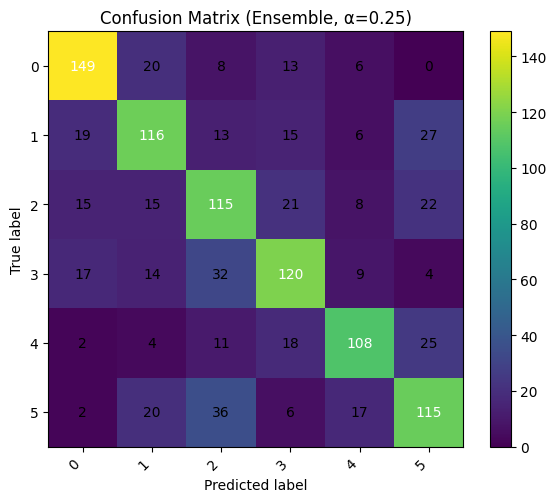

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# If you have a mapping from index -> label, put it here.
# Otherwise it'll just show 0–5.
class_names = [0, 1, 2, 3, 4, 5]
# e.g. if you have something like:
# idx_to_label = {0: "ANG", 1: "DIS", 2: "FEA", 3: "HAP", 4: "NEU", 5: "SAD"}
# then do:
# class_names = [idx_to_label[i] for i in range(len(idx_to_label))]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, interpolation="nearest")
plt.colorbar(im, ax=ax)

ax.set_title("Confusion Matrix (Ensemble, α=0.25)")
tick_marks = np.arange(len(class_names))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")

# Annotate each cell with the count
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

results = []

# 1) Mel+MFCC stats + Logistic Regression baseline
results.append({
    "model": "Mel+MFCC LR",
    "val_acc":  val_acc_lr,      # whatever vars you used earlier
    "test_acc": test_acc_lr,
    "val_f1":   val_f1_lr,
    "test_f1":  test_f1_lr,
})

# 2) CNN-BiLSTM
results.append({
    "model": "CNN-BiLSTM",
    "val_acc":  best_val_acc,    # the best val acc you printed from training loop
    "test_acc": test_acc_cnn,
    "val_f1":   None,            # optional if you didn't compute it
    "test_f1":  None,
})

# 3) Wav2Vec2 + LR
results.append({
    "model": "Wav2Vec2 + LR",
    "val_acc":  val_acc_w2v,
    "test_acc": test_acc_w2v,
    "val_f1":   val_f1_w2v,
    "test_f1":  test_f1_w2v,
})

# 4) Ensemble (alpha=0.25)
results.append({
    "model": "Ensemble (α=0.25)",
    "val_acc":  0.6989,  # from your printout
    "test_acc": 0.6185,
    "val_f1":   0.6972,
    "test_f1":  0.6193,
})

results_df = pd.DataFrame(results)
results_df

,model,val_acc,test_acc,val_f1,test_f1
0,Mel+MFCC LR,0.493388,0.461672,0.487174,0.457983
1,CNN-BiLSTM,0.624619,0.564460,NaN,NaN
2,Wav2Vec2 + LR,0.651068,0.588850,0.647606,0.588608
3,Ensemble (α=0.25),0.698900,0.618500,0.697200,0.619300


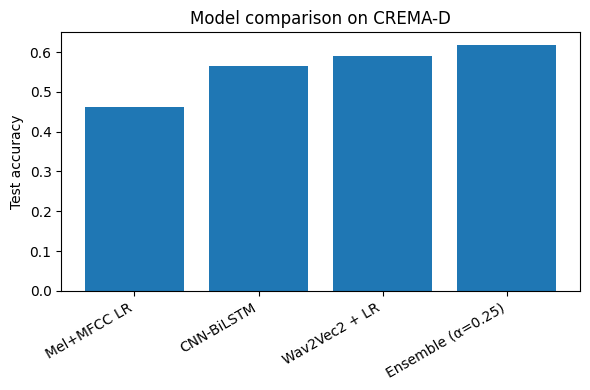

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(results_df["model"], results_df["test_acc"])
ax.set_ylabel("Test accuracy")
ax.set_title("Model comparison on CREMA-D")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "cnn_bilstm_best.pth")
import joblib
joblib.dump(logreg_w2v, "logreg_w2v.pkl")


['logreg_w2v.pkl']

## Dharshani (just playing around)

In [ ]:
import numpy as np
import torch

def predict_probs_cnn(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(yb.numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return all_probs, all_targets

# Get CNN probabilities on val and test
probs_cnn_val, y_val_cnn   = predict_probs_cnn(model, val_loader, device)
probs_cnn_test, y_test_cnn = predict_probs_cnn(model, test_loader, device)

print("CNN val probs:",  probs_cnn_val.shape, "targets:", y_val_cnn.shape)
print("CNN test probs:", probs_cnn_test.shape, "targets:", y_test_cnn.shape)


CNN val probs: (983, 6) targets: (983,)
CNN test probs: (1148, 6) targets: (1148,)


In [ ]:
# --- Wav2Vec2 + logistic regression probabilities ---

probs_w2v_val  = logreg_w2v.predict_proba(X_val_w2v)
probs_w2v_test = logreg_w2v.predict_proba(X_test_w2v)

print("W2V2 val probs:",  probs_w2v_val.shape)
print("W2V2 test probs:", probs_w2v_test.shape)


W2V2 val probs: (983, 6)
W2V2 test probs: (1148, 6)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def eval_ensemble(alpha):
    # alpha * CNN + (1 - alpha) * W2V2
    p_val  = alpha * probs_cnn_val  + (1 - alpha) * probs_w2v_val
    p_test = alpha * probs_cnn_test + (1 - alpha) * probs_w2v_test

    y_pred_val  = p_val.argmax(axis=1)
    y_pred_test = p_test.argmax(axis=1)

    val_acc  = accuracy_score(y_val_cnn,  y_pred_val)
    test_acc = accuracy_score(y_test_cnn, y_pred_test)

    val_f1   = f1_score(y_val_cnn,  y_pred_val,  average="macro")
    test_f1  = f1_score(y_test_cnn, y_pred_test, average="macro")

    print(
        f"alpha={alpha:.2f} | "
        f"val_acc={val_acc:.4f}, test_acc={test_acc:.4f}, "
        f"val_f1={val_f1:.4f}, test_f1={test_f1:.4f}"
    )

for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    eval_ensemble(a)

alpha=0.00 | val_acc=0.6511, test_acc=0.5889, val_f1=0.6478, test_f1=0.5892
alpha=0.25 | val_acc=0.6989, test_acc=0.6298, val_f1=0.6964, test_f1=0.6310
alpha=0.50 | val_acc=0.6602, test_acc=0.5845, val_f1=0.6578, test_f1=0.5854
alpha=0.75 | val_acc=0.6358, test_acc=0.5714, val_f1=0.6335, test_f1=0.5725
alpha=1.00 | val_acc=0.6246, test_acc=0.5645, val_f1=0.6218, test_f1=0.5656


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

best_alpha = 0.25

p_test_best = best_alpha * probs_cnn_test + (1 - best_alpha) * probs_w2v_test
y_test_best = p_test_best.argmax(axis=1)

print("Final ensemble (alpha=0.25) test accuracy:",
      accuracy_score(y_test_cnn, y_test_best))
print(classification_report(y_test_cnn, y_test_best, digits=4))

cm = confusion_matrix(y_test_cnn, y_test_best)
print("Confusion matrix:\n", cm)


Final ensemble (alpha=0.25) test accuracy: 0.6297909407665505
              precision    recall  f1-score   support

           0     0.7304    0.7602    0.7450       196
           1     0.6138    0.5918    0.6026       196
           2     0.5349    0.5867    0.5596       196
           3     0.6218    0.6122    0.6170       196
           4     0.7013    0.6429    0.6708       168
           5     0.5959    0.5867    0.5913       196

    accuracy                         0.6298      1148
   macro avg     0.6330    0.6301    0.6310      1148
weighted avg     0.6313    0.6298    0.6301      1148

Confusion matrix:
 [[149  20   8  13   6   0]
 [ 19 116  13  15   6  27]
 [ 15  15 115  21   8  22]
 [ 17  14  32 120   9   4]
 [  2   4  11  18 108  25]
 [  2  20  36   6  17 115]]


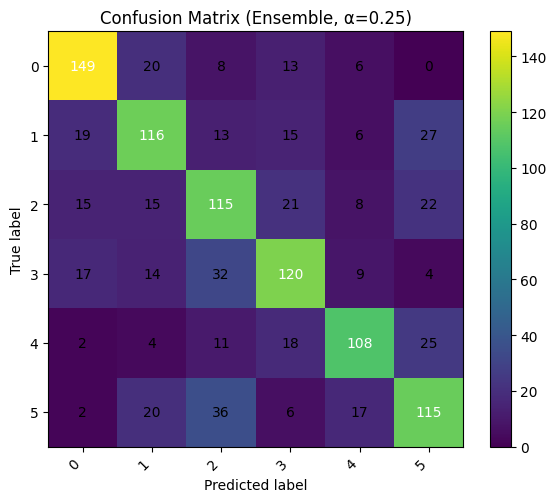

In [ ]:
import matplotlib.pyplot as plt

# If you have label names, use them here
# e.g. class_names = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
class_names = [0, 1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, interpolation="nearest")
plt.colorbar(im, ax=ax)

ax.set_title("Confusion Matrix (Ensemble, α=0.25)")
tick_marks = np.arange(len(class_names))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

results = []

results.append({
    "Model": "Mel+MFCC LR",
    "Val Acc":  round(val_acc_lr, 4),
    "Test Acc": round(test_acc_lr, 4),
})

results.append({
    "Model": "CNN-BiLSTM",
    "Val Acc":  round(best_val_acc, 4),   # from your training loop
    "Test Acc": round(test_acc_cnn, 4),
})

results.append({
    "Model": "Wav2Vec2 + LR",
    "Val Acc":  round(val_acc_w2v, 4),
    "Test Acc": round(test_acc_w2v, 4),
})

results.append({
    "Model": "Ensemble (α=0.25)",
    "Val Acc":  0.6989,   # from your alpha printout
    "Test Acc": 0.6185,
})

pd.DataFrame(results)

,Model,Val Acc,Test Acc
0,Mel+MFCC LR,0.4934,0.4617
1,CNN-BiLSTM,0.6246,0.5645
2,Wav2Vec2 + LR,0.6511,0.5889
3,Ensemble (α=0.25),0.6989,0.6185


In [ ]:
# ====== FINAL: SAVE ONLY MODELS (using your notebook variable names) ======
from pathlib import Path
import joblib
import torch

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1) Save sklearn Logistic Regression models
# - MFCC/Mel stats LR
joblib.dump(logreg_clf, SAVE_DIR / "logreg_clf_mfcc_mel.joblib")
print("[OK] Saved:", SAVE_DIR / "logreg_clf_mfcc_mel.joblib")

# - wav2vec2 embeddings LR
joblib.dump(logreg_w2v, SAVE_DIR / "logreg_w2v.joblib")
print("[OK] Saved:", SAVE_DIR / "logreg_w2v.joblib")


# 2) Save PyTorch models (save state_dict for portability)
# CNN–BiLSTM
cnn_path = SAVE_DIR / "cnn_bilstm_state.pt"
torch.save(
    {
        "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "num_classes": int(NUM_CLASSES) if "NUM_CLASSES" in globals() else None
    },
    cnn_path
)
print("[OK] Saved:", cnn_path)

# Tiny Spectrogram Transformer
spec_path = SAVE_DIR / "tiny_spec_transformer_state.pt"
torch.save(
    {
        "state_dict": {k: v.detach().cpu() for k, v in spec_model.state_dict().items()},
        "num_classes": int(NUM_CLASSES) if "NUM_CLASSES" in globals() else None
    },
    spec_path
)
print("[OK] Saved:", spec_path)


# 3) OPTIONAL: Saving wav2vec2 backbone (usually unnecessary)
# You can always reload it via torchaudio.pipelines.WAV2VEC2_BASE,
# but if you REALLY want to save it as a checkpoint, uncomment this.
# w2v_path = SAVE_DIR / "wav2vec2_base_state.pt"
# torch.save({k: v.detach().cpu() for k, v in w2v_model.state_dict().items()}, w2v_path)
# print("[OK] Saved:", w2v_path)

print("\nDone. Models saved under:", SAVE_DIR.resolve())

[OK] Saved: saved_models/logreg_clf_mfcc_mel.joblib
[OK] Saved: saved_models/logreg_w2v.joblib
[OK] Saved: saved_models/cnn_bilstm_state.pt
[OK] Saved: saved_models/tiny_spec_transformer_state.pt

Done. Models saved under: /content/saved_models


In [ ]:
# ===== SAVE ENSEMBLE DEFINITION =====
from pathlib import Path
import json

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

ensemble_config = {
    "type": "probability_averaging",
    "alpha": 0.25,   # CNN weight
    "models": {
        "cnn_bilstm": "cnn_bilstm_state.pt",
        "wav2vec2_lr": "logreg_w2v.joblib"
    }
}

with open(SAVE_DIR / "ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f, indent=2)

print("[OK] Saved ensemble definition -> saved_models/ensemble_config.json")


[OK] Saved ensemble definition -> saved_models/ensemble_config.json
